# Integrering av fornybar energi

Når vi tar for oss integrasjon av fornybar energi i distribusjonsnettet, fokuser vi på hvordan vi skal koble strømkilder som sol og vind til kraftnettet. Som beskrevet i 3D (De tre D'ene; Dekarboniseering, Digitalisering, Desentralisering) rammeverket og FN's visjon om [ren energi for alle](https://fn.no/om-fn/fns-baerekraftsmaal/ren-energi-til-alle) er vi forpliktet til å sikre tilgang til pålitelig, bærekraftig og moderne energi for alle. Andelen ren energi er høy i Norge på grunn av vannkraften, men er avhengig av mengde vann som tilsig til vannmagasinene. Sol- og vindkraft er viktige bidrag for å oppnå bærekraftsmålene i tilegg har de større grad av skalerbarhet enn vannkraft. Men sol- og vindkraftens intermittente (periodevis, dvs. ujevn produksjon) natur kompliserer de dynamiske forholdene og stabiliteten i kraftnettet. 

In [1]:
# TEST CELL
#from IPython.display import Image, display
#display(Image("images/SDG7.png"))

## Modellering og simulering
Vi må derfor simulere tilstander som kan oppstå for å kunne analysere integreringen av fornybare energikilder på nettet. De kjente transmisjonslinjemodellene må da utvides til å ta opp i seg dynamiske forandringer i nettet, som vist i {numref}`fig-revers-flyt`. De tradisjonelle metodene ($\pi$-metoden) modellerer vanligvis enveis effektflyt. Med skalerbar lokal produksjon kan strømmen tidvis gå motsatt vei:
- solceller
- vindkraft
- batterier
- elbiler med V2G (Vehicle-to-Grid)



In [2]:
# TEST CELL
from myst_nb import glue
from IPython.display import SVG

svg = """
<svg width="900" height="260"
     xmlns="http://www.w3.org/2000/svg">

  <defs>
    <marker id="arrow"
            markerWidth="10"
            markerHeight="10"
            refX="9"
            refY="3"
            orient="auto">
      <path d="M0,0 L10,3 L0,6 z"
            fill="black"/>
    </marker>
  </defs>

  <!-- Busser -->

  <line x1="60" y1="70"
        x2="60" y2="130"
        stroke="gray"
        stroke-width="8"/>

  <line x1="380" y1="70"
        x2="380" y2="130"
        stroke="gray"
        stroke-width="8"/>

  <line x1="700" y1="70"
        x2="700" y2="130"
        stroke="gray"
        stroke-width="8"/>

  <!-- Linjer -->

  <line x1="60" y1="100"
        x2="380" y2="100"
        stroke="black"
        stroke-width="3"/>

  <line x1="380" y1="100"
        x2="700" y2="100"
        stroke="black"
        stroke-width="3"/>

  <!-- Effektflyt -->

  <line x1="160" y1="85"
        x2="290" y2="85"
        stroke="black"
        stroke-width="3"
        marker-end="url(#arrow)" />

  <text x="175" y="65"
        font-size="20">
        P
  </text>

  <line x1="500" y1="85"
        x2="610" y2="85"
        stroke="black"
        stroke-width="3"
        marker-end="url(#arrow)" />

  <text x="515" y="65"
        font-size="20">
        P
  </text>

  <!-- Grid -->

  <text x="25" y="45"
        font-size="22">
        Grid
  </text>

  <!-- Bus-navn -->

  <text x="340" y="45"
        font-size="22">
        Bus 1
  </text>

  <text x="660" y="45"
        font-size="22">
        Bus 2
  </text>

  <!-- Last 1 -->

  <line x1="380" y1="100"
        x2="380" y2="150"
        stroke="black"
        stroke-width="2"/>

  <line x1="380" y1="150"
        x2="460" y2="150"
        stroke="black"
        stroke-width="2"
        marker-end="url(#arrow)"/>

  <text x="470" y="157"
        font-size="20">
        Last 1
  </text>

  <!-- Last 2 -->

  <line x1="700" y1="100"
        x2="700" y2="190"
        stroke="black"
        stroke-width="2"/>

  <line x1="700" y1="150"
        x2="760" y2="150"
        stroke="black"
        stroke-width="2"
        marker-end="url(#arrow)"/>

  <text x="760" y="157"
        font-size="20">
        Last 2
  </text>

<!-- PV -->

  <line x1="700" y1="100"
        x2="700" y2="190"
        stroke="black"
        stroke-width="2"/>

  <line x1="760" y1="190"
        x2="700" y2="190"
        stroke="black"
        stroke-width="2"
        marker-end="url(#arrow)"/>

  <text x="760" y="197"
        font-size="20">
        PV
  </text>

  <!-- Spenninger -->

  <text x="5" y="190"
        font-size="20">
        V₀ = 1.000 pu
  </text>

  <text x="320" y="190"
        font-size="20">
        V₁ = ?
  </text>

  <text x="640" y="230"
        font-size="20">
        V₂ = ?
  </text>

</svg>
"""

glue("revers_flyt", SVG(svg), display=False)

```{glue:figure} revers_flyt
:name: fig-revers-flyt

Reversibel effektflyt på noder med PV-produksjon
```

#### Reversibel effektflyt
Den reversible effektflyten fra større andel distribuert produksjon kan gi høyere lokale spenninger, endrede kortslutningsforhold og komplisere vernkoordineringen. Vi må derfor ha noen simuleringsverktøy for å analysere disse forholdene.

#### IBR

Sol- og Vindkraft er også basert på invertering (vekselretting) av signalet fra DC til AC og kalles derfor Inverter Based Resources (IBR). Omformingen skjer med kraftelektronikk uten inertian som den roterende masse bidrar med.

##### Vindkraft

Selv om Vindtubiner roterer må signalet først likerettes (AC/DC) også vekselrettes (DC/DC) i en operasjon som kalles back-to-back (rygg-mot-rygg) som illustrert i {numref}`fig-wind-converter`. DC-linken fungerer som et energilager med liten kapasitet som stabiliserer likespenningen mellom omformerne. Den frikobler generatorsiden fra nettsiden slik at generatoren kan operere med variabel frekvens, mens inverteren leverer en kontrollert spenning med 50 Hz til nettet.

In [3]:
# TEST CELL
from myst_nb import glue
from IPython.display import SVG

svg = """
<svg xmlns="http://www.w3.org/2000/svg"
     width="844" height="232"
     viewBox="0 0 844 232">

  <!-- Bakgrunn -->
  <rect width="844" height="232" fill="#e8e8e8"/>

  <!-- Enkel vindturbin -->
  <g transform="translate(90,116)">
    <!-- Nav -->
    <circle cx="0" cy="0"
            r="12"
            fill="white"
            stroke="green"
            stroke-width="4"/>

    <!-- Mast -->
    <line x1="0" y1="12"
          x2="0" y2="90"
          stroke="green"
          stroke-width="6"/>

    <!-- Blader -->
    <line x1="0" y1="0"
          x2="-35" y2="-55"
          stroke="green"
          stroke-width="8"
          stroke-linecap="round"/>

    <line x1="0" y1="0"
          x2="45" y2="0"
          stroke="green"
          stroke-width="8"
          stroke-linecap="round"/>

    <line x1="0" y1="0"
          x2="-15" y2="55"
          stroke="green"
          stroke-width="8"
          stroke-linecap="round"/>
  </g>

  <!-- Trefaseledere fra turbin -->
  <line x1="102" y1="70"  x2="235" y2="70"
        stroke="red" stroke-width="3"/>

  <line x1="102" y1="122" x2="235" y2="122"
        stroke="#d8d800" stroke-width="3"/>

  <line x1="102" y1="174" x2="235" y2="174"
        stroke="blue" stroke-width="3"/>

  <!-- Omformer 1 -->
  <rect x="235" y="35"
        width="135" height="170"
        fill="#89AADF"
        stroke="#5F79A6"
        stroke-width="3"/>

  <!-- Refleks -->
  <line x1="245" y1="200"
        x2="365" y2="40"
        stroke="white"
        stroke-width="4"
        opacity="0.35"/>

  <!-- AC-symbol -->
  <path d="M255 82
           C265 68, 275 68, 285 82
           C295 96, 305 96, 315 82"
        fill="none"
        stroke="#FFD9B5"
        stroke-width="8"/>

  <!-- DC-symbol -->
  <rect x="298" y="125" width="44" height="8"
        fill="#FFF4A5" stroke="#B8B080"/>

  <rect x="298" y="138" width="44" height="8"
        fill="#FFF4A5" stroke="#B8B080"/>

  <!-- DC-link -->
  <line x1="370" y1="70"
        x2="495" y2="70"
        stroke="black"
        stroke-width="3"/>

  <line x1="370" y1="190"
        x2="495" y2="190"
        stroke="black"
        stroke-width="3"/>

  <!-- Kondensator -->
  <line x1="432" y1="70"
        x2="432" y2="108"
        stroke="black"
        stroke-width="4"/>

  <line x1="420" y1="108"
        x2="444" y2="108"
        stroke="black"
        stroke-width="4"/>

  <line x1="420" y1="118"
        x2="444" y2="118"
        stroke="black"
        stroke-width="4"/>

  <line x1="432" y1="118"
        x2="432" y2="190"
        stroke="black"
        stroke-width="4"/>

  <!-- Omformer 2 -->
  <rect x="495" y="35"
        width="135" height="170"
        fill="#89AADF"
        stroke="#5F79A6"
        stroke-width="3"/>

  <!-- Refleks -->
  <line x1="505" y1="200"
        x2="625" y2="40"
        stroke="white"
        stroke-width="4"
        opacity="0.35"/>

  <!-- DC-symbol -->
  <rect x="515" y="58" width="44" height="8"
        fill="#FFF4A5" stroke="#B8B080"/>

  <rect x="515" y="71" width="44" height="8"
        fill="#FFF4A5" stroke="#B8B080"/>

  <!-- AC-symbol -->
  <path d="M560 145
           C570 131, 580 131, 590 145
           C600 159, 610 159, 620 145"
        fill="none"
        stroke="#FFD9B5"
        stroke-width="8"/>

  <!-- Trefaseledere til nett -->
  <line x1="630" y1="70"
        x2="770" y2="70"
        stroke="red"
        stroke-width="3"/>

  <line x1="630" y1="122"
        x2="770" y2="122"
        stroke="#d8d800"
        stroke-width="3"/>

  <line x1="630" y1="174"
        x2="770" y2="174"
        stroke="blue"
        stroke-width="3"/>

  <!-- Grid-symbol -->
  <line x1="720" y1="40"
        x2="720" y2="200"
        stroke="black"
        stroke-width="3"/>

  <!-- Vertikal tekst -->
  <text x="730"
        y="60"
        font-family="Times New Roman"
        font-size="22"
        font-weight="bold"
        >
    P_grid
  </text>

 <!-- Vertikal tekst -->
  <text x="160"
        y="60"
        font-family="Times New Roman"
        font-size="22"
        font-weight="bold"
        >
    P_gen
  </text>

</svg>
"""

glue("wind_converter", SVG(svg), display=False)

```{glue:figure} wind_converter
:name: fig-wind-converter

Back-to-back omformer for vindturbin.
```

Begge omformerne genererer PWM-signaler som gir høyfrekvente effektpulser. Momentant kan effekten på generatorsiden og nettsiden være forskjellig:

$$
P_{gen}(t) \neq P_{nett}(t)
$$

Selv om middelverdien over tid er den samme må DC-linken absorbere differansen mellom effekten inn og ut:

$$
P_C = P_{gen} - P_{nett}
$$

hvor $P_C$ er effekten som til enhver tid lagres eller frigjøres av DC-link-kondensatoren.
Energien i kondensatoren varierer dermed i henhold til:

$$
\frac{dE}{dt}=P_C
$$

Den lagrede energien i DC-linken er gitt ved:

$$
E=\frac{1}{2}CV_{dc}^{2}
$$

der

- E er lagret energi [J]
- C er kapasitansen [F]
- $V_{dc}$ er DC-linkspenningen [V]

Hvis kondensatoren er for liten, vil energiinnholdet variere merkbart, noe som fører til spenningssvingninger i DC-linken.
DC-linkens hovedoppgave er derfor å fungere som en energibuffer som glatter ut effekt- og spenningsrippel mellom de to PWM-omformerne og opprettholder en mest mulig konstant DC-spenning.

##### Solkraft

For at solkraften skal kunne integreres på net må den inverteres (vekselretter) i en inverter, som i {numref}`fig-pv-inverter`. 

In [4]:
# TEST CELL
from myst_nb import glue
from IPython.display import SVG

svg = """
<svg xmlns="http://www.w3.org/2000/svg"
     width="900"
     height="260"
     viewBox="0 0 900 260">

  <style>
    .wire { stroke:black; stroke-width:4; fill:none; }
    .label { font-family:Arial, sans-serif; font-size:18px; }
    .small { font-family:Arial, sans-serif; font-size:15px; }
  </style>

  <!-- ========================= -->
  <!-- PV ARRAY -->
  <!-- ========================= -->

  <circle cx="70" cy="45" r="18" fill="gold"/>

  <rect x="40" y="85" width="90" height="90"
        fill="#5d87c5"
        stroke="#333"
        stroke-width="2"/>

  <line x1="55" y1="85" x2="55" y2="175" stroke="white"/>
  <line x1="75" y1="85" x2="75" y2="175" stroke="white"/>
  <line x1="95" y1="85" x2="95" y2="175" stroke="white"/>
  <line x1="115" y1="85" x2="115" y2="175" stroke="white"/>

  <line x1="40" y1="105" x2="130" y2="105" stroke="white"/>
  <line x1="40" y1="125" x2="130" y2="125" stroke="white"/>
  <line x1="40" y1="145" x2="130" y2="145" stroke="white"/>

  <text x="37" y="215" class="label">PV Array</text>

  <!-- ========================= -->
  <!-- INPUT DC -->
  <!-- ========================= -->

  <line x1="130" y1="110" x2="220" y2="110" class="wire"/>
  <line x1="130" y1="150" x2="220" y2="150" class="wire"/>



  <!-- ========================= -->
  <!-- DC/DC -->
  <!-- ========================= -->

  <rect x="220"
        y="75"
        width="120"
        height="110"
        rx="12"
        fill="#466eab"
        stroke="#25457b"
        stroke-width="4"/>

  <!-- diagonal -->
  <line x1="245" y1="160"
        x2="315" y2="90"
        stroke="white"
        stroke-width="4"/>

  <!-- upper DC symbol -->
  <line x1="248" y1="98"
        x2="278" y2="98"
        stroke="white"
        stroke-width="5"/>

  <line x1="248" y1="110"
        x2="278" y2="110"
        stroke="white"
        stroke-width="5"/>

  <!-- lower DC symbol -->
  <line x1="282" y1="145"
        x2="312" y2="145"
        stroke="white"
        stroke-width="5"/>

  <line x1="282" y1="157"
        x2="312" y2="157"
        stroke="white"
        stroke-width="5"/>



  <text x="247" y="223" class="label">DC/DC</text>

  <!-- ========================= -->
  <!-- DC LINK -->
  <!-- ========================= -->

  <line x1="340" y1="110"
        x2="500" y2="110"
        class="wire"/>

  <line x1="340" y1="150"
        x2="500" y2="150"
        class="wire"/>

  <text x="350" y="103"
        font-size="20"
        font-weight="bold">+</text>

  <text x="352" y="165"
        font-size="20"
        font-weight="bold">−</text>

  <text x="390" y="55"
        class="label">DC Link</text>

  <text x="400" y="95"
        class="small"
        font-style="italic">Vdc</text>

  <!-- capacitor -->
  <line x1="420" y1="110"
        x2="420" y2="122"
        stroke="black"
        stroke-width="3"/>

  <line x1="405" y1="122"
        x2="435" y2="122"
        stroke="black"
        stroke-width="5"/>

  <line x1="405" y1="138"
        x2="435" y2="138"
        stroke="black"
        stroke-width="5"/>

  <line x1="420" y1="138"
        x2="420" y2="150"
        stroke="black"
        stroke-width="3"/>

  <text x="445" y="134" class="small">Cdc</text>

  <!-- ========================= -->
  <!-- VSC INVERTER -->
  <!-- ========================= -->

  <rect x="500"
        y="75"
        width="120"
        height="110"
        rx="12"
        fill="#8db1ee"
        stroke="#5676ab"
        stroke-width="4"/>

  <!-- diagonal -->
  <line x1="520" y1="165"
        x2="600" y2="85"
        stroke="white"
        stroke-width="4"
        opacity="0.7"/>

 <!-- DC symbol øverst -->
<line x1="525" y1="100"
      x2="560" y2="100"
      stroke="#efe083"
      stroke-width="5"/>

<line x1="525" y1="113"
      x2="560" y2="113"
      stroke="#efe083"
      stroke-width="5"/>

<!-- AC symbol nederst -->
<text x="570"
      y="170"
      font-size="60"
      text-anchor="middle"
      fill="#ffd0a0">~</text>

  <text x="532" y="223" class="label">VSC</text>

  <!-- ========================= -->
  <!-- FILTER -->
  <!-- ========================= -->

  <line x1="620" y1="130"
        x2="655" y2="130"
        class="wire"/>

  <path d="
      M655 130
      q10 -15 20 0
      q10 -15 20 0
      q10 -15 20 0"
      stroke="black"
      stroke-width="3"
      fill="none"/>

  <line x1="715" y1="130"
        x2="760" y2="130"
        class="wire"/>

  <text x="675" y="105"
        class="small">L</text>

  <!-- ========================= -->
  <!-- GRID -->
  <!-- ========================= -->

  <line x1="780"
        y1="70"
        x2="780"
        y2="190"
        stroke="black"
        stroke-width="5"/>

  <line x1="760" y1="105"
        x2="840" y2="105"
        stroke="red"
        stroke-width="4"/>

  <line x1="760" y1="130"
        x2="840" y2="130"
        stroke="gold"
        stroke-width="4"/>

  <line x1="760" y1="155"
        x2="840" y2="155"
        stroke="blue"
        stroke-width="4"/>

  <text x="800"
        y="220"
        class="label">Grid</text>

</svg>
"""

glue("pv_inverter", SVG(svg), display=False)

```{glue:figure} pv_inverter
:name: fig-pv-inverter

Omforming i en solcelle
```

DC-DC omformeren holder spennigsnivået stabilt, selv om det er fluktuerende solinnstråling på solcellen. Kondensatoren lagrer energi i DC-linken før det stabile signalet vekselrettes til nettet. Spolen L glatter ut PWM-generert strømrippel fra inverteren, reduserer harmoniske som sendes ut på nettet og gjør det mulig å regulere aktiv og reaktiv effekt på en kontrollert måte. Det fungerer som det viktigste filterelementet mellom VSC-en og kraftnettet.

### P_{conv}

Det er nyttig å kunne modellere tapene i omforming av signaler. Omformertapene kan modelleres som $P_{conv}$

#### Pandapower
Pandapower kombinerer [pandas](https://pandas.pydata.org/docs/) biblioteket med kraftflytsolveren [PYPOWER](https://pypower.readthedocs.io/en/latest/index.html). Den muliggjør løsnig på problemer tilknyttet reversibel effektflyt.

### Kall på statistikken 

Statistisk sentralbyrå tilbyr mye forskjellig statistikk i [statistikkkbanken](https://www.ssb.no/statbank/).
For å vise problemstillingens aktualitet gjør vi et API-kall til statistikkbanken til Statistisk SentralByrå (SSB).  `requests` henter dataene og `pyjstat` leser, tolker og deretter bygger en tabellstruktur. Vi skal be python sende en post forespørsel til SSB (requests.post(url, json=query).text) i en query som bruker JSON-kode, der SSB returnerer svaret i et JASON-stat-format.

Inne i statistikkbanken finner vi en tabell som sier *08307: Produksjon, import, eksport og forbruk av elektrisk kraft (GWh), etter år.*

Kilden er SSBs [tabell 08307](https://www.ssb.no/statbank/table/08307).



## Utvikle query 

Vi bruker metadata (data om datene) tl å utvikle en query, eller en spørring mot databasen.

Først importeres biblioteket request og det bruker vi til å sjekke om vi får kontakt med nettstedet eller databasen

In [34]:
import requests
api_url = "https://data.ssb.no/api/v0/no/table/08307"
response = requests.get(api_url)
print(response.status_code)

200


Metoden .json() gir oss innholdet i repsonsen. Dette er metadata som gir dat om dataen.

In [38]:
metadata = response.json()
print(metadata)

{'title': '08307: Produksjon, import, eksport og forbruk av elektrisk kraft (GWh), etter statistikkvariabel og år', 'variables': [{'code': 'ContentsCode', 'text': 'statistikkvariabel', 'values': ['ProdTotal', 'VannKraft', 'VindKraft', 'Solkraft', 'VarmeKraft', 'Import', 'Eksport', 'Bruttoforbruk', 'ForbrukKraftStasj', 'Pumpekraftforbruk', 'TapStatistDiff', 'Nettoforbruk'], 'valueTexts': ['Produksjon i alt', 'Vannkraftproduksjon', 'Vindkraftproduksjon', 'Solkraftproduksjon', 'Varmekraftproduksjon', 'Import', 'Eksport', 'Bruttoforbruk', 'Forbruk i kraftstasjonene (-2019)', 'Pumpekraftforbruk', 'Tap og statistisk differanse', 'Nettoforbruk']}, {'code': 'Tid', 'text': 'år', 'values': ['1950', '1955', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996'

In [32]:
print(response)

<Response [200]>


Hvilke metadata inneholder tabellen:

In [7]:
meta = requests.get(f"https://data.ssb.no/api/v0/no/table/08307").json()

print("Tittel:")
print(meta["title"])

Tittel:
08307: Produksjon, import, eksport og forbruk av elektrisk kraft (GWh), etter statistikkvariabel og år


In [8]:
TABLE = "08307"

Et `query` bestemmer hvilke data som skal hentes og `response` hvordan dataene returneres. I `ContentsCode` finner vi flere statistikkvariabler `selection` velger verdiene det skal filtreres på `filter:item`angir de eksakte verdiene, som velges i `VARIABLES`. Før vi kan gjøre det må vi finne de riktige kodene. De ligger i metadata, som er data om data.

In [9]:
import requests

url = "https://data.ssb.no/api/v0/no/table/08307/"

metadata = requests.get(url).json()

for var in metadata["variables"]:
    print(f"\nKode: {var['code']}")
    print(f"Tekst: {var['text']}")
    print(f"Antall verdier: {len(var['values'])}")


Kode: ContentsCode
Tekst: statistikkvariabel
Antall verdier: 12

Kode: Tid
Tekst: år
Antall verdier: 68


Altså 12 statistikkvariabler. La oss se nermære på de:

In [10]:
for var in metadata["variables"]:
    if var["code"] == "ContentsCode":
        print(var["valueTexts"])

['Produksjon i alt', 'Vannkraftproduksjon', 'Vindkraftproduksjon', 'Solkraftproduksjon', 'Varmekraftproduksjon', 'Import', 'Eksport', 'Bruttoforbruk', 'Forbruk i kraftstasjonene (-2019)', 'Pumpekraftforbruk', 'Tap og statistisk differanse', 'Nettoforbruk']


Da velger vi ut sol- og vindkraft som variabler:

In [11]:
VARIABLES = ["VindKraft", "Solkraft"]

I JSON-stat-baserte API-er (som SSB), er strukturen for en spørring ofte:
    
```json
query = {
    "query": [
        {
            "code": "...",
            "selection": {
                "filter": "...",
                "values": [...]
            }
        }
    ],
    "response": {
        "format": "json-stat2"
    }
}
```

Nå vet vi:
Det du må finne ut er:

- Hvilke dimensjoner finnes? (code)
- Hvilke verdier finnes innen hver dimensjon? (values)
- Hvilket filter skal brukes? (ofte "item")

In [12]:
query = {
    "query": [{
        "code": "ContentsCode",
        "selection": {
            "filter": "item",
            "values": VARIABLES
        }
    }],
    "response": {"format": "json-stat2"}
}

Vi kaller opp nettstedet og ber `pyjstat` lese `df` og returnere tabell:

In [13]:
url = f"https://data.ssb.no/api/v0/en/table/{TABLE}"

df = pyjstat.Dataset.read(
    requests.post(url, json=query).text
).write("dataframe")

`df.pivot`gjør om til bredt format, og vi indekserer på år `index:year`:

In [14]:
df_wide = df.pivot(
    index="year",
    columns="contents",
    values="value"
)

df_wide = df_wide.rename(columns={
    "Wind power production": "Vind",
    "Solar power production": "Sol"
})



In [15]:
# TEST CELL
df_wide = (
    df.pivot(
        index="year",
        columns="contents",
        values="value"
    )
    .reset_index()
)

df_wide = df_wide.rename(columns={
    "Wind power production": "Vind",
    "Solar power production": "Sol"
})

# Konverter år til datetime og sett som indeks
df_wide["year"] = pd.to_datetime(df_wide["year"], format="%Y")

df_wide = df_wide.set_index("year")

df_wide.index = pd.PeriodIndex(
    df_wide.index.year,
    freq="Y"
)
#print(df_wide.tail(7).to_markdown())

### Norsk sol- og vindkraft

API-kallet kan genereres som en dataframe som gir historiske tall, som vist i {numref}`tab-sol-vind`, over sol og vindkraftproduksjonen i Norge.

```{table} Sol- og vindkraftproduksjon i Norge (GWh)
:name: tab-sol-vind

| År | Sol | Vind |
|---:|---:|---:|
| 2019 | NaN | 5525 |
| 2020 | 25 | 9911 |
| 2021 | 33 | 11768 |
| 2022 | 63 | 14810 |
| 2023 | 165 | 13965 |
| 2024 | 251 | 14545 |
| 2025 | 348 | 13899 |
```

Vi plotter dataene som synliggjør den historiske utviklingen av sol- og vindkraft i {numref}`fig-sol-vind`.

In [16]:
# TEST CELL
import matplotlib.pyplot as plt
from myst_nb import glue

ax = df_wide[df_wide.index.year >= 1990][["Sol", "Vind"]].plot(
    figsize=(10, 5),
    marker="o"
)
from datetime import date

plt.figtext(
    0.01, 0.01,
    f"Kilde: SSB Statistikkbanken API, tabell 08307. "
    f"Hentet {date.today():%d.%m.%Y}",
    ha="left",
    fontsize=8,
    color="gray"
);
ax.set_title("Kraftproduksjon fra sol og vind");
ax.set_ylabel("GWh");

glue("fig-sol-vind", ax.figure, display=False)
plt.close(ax.figure)

```{glue:figure} fig-sol-vind
---
name: fig-sol-vind
width: 90%
---
Produksjon av sol- og vindkraft i Norge.

Kilde: SSB Statistikkbanken API, tabell 08307.
```

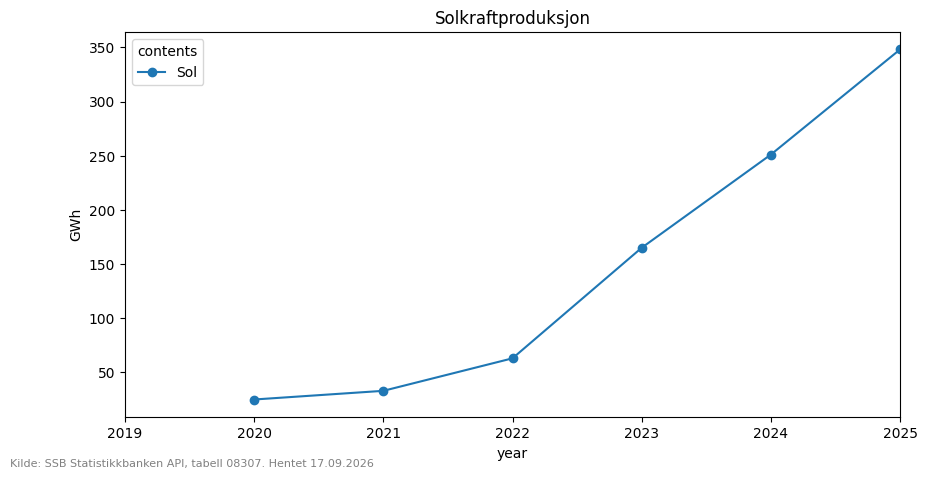

In [17]:
# TEST CELL
ax = df_wide[df_wide.index.year >= 2019][["Sol"]].plot(
    figsize=(10, 5),
    marker="o"
)
ax.set_title("Solkraftproduksjon")
ax.set_ylabel("GWh")

from datetime import date

plt.figtext(
    0.01, 0.01,
    f"Kilde: SSB Statistikkbanken API, tabell 08307. "
    f"Hentet {date.today():%d.%m.%Y}",
    ha="left",
    fontsize=8,
    color="gray"
);

In [18]:
# TEST CELL
TABLE = "08307"
SOURCE = f"https://www.ssb.no/statbank/table/{TABLE}"

print(f"Kilde: SSB Statistikkbanken, tabell {TABLE}")
print(SOURCE)

Kilde: SSB Statistikkbanken, tabell 08307
https://www.ssb.no/statbank/table/08307


### Endrede tilsig

Norge har 1600 vannkraftverk og omtrent 1200 innsjøer regulert til kraftproduksjon, som gjør det mulig å lagre kraft innenfor reguleringsintervallene lavest regulerte vannstand (LRV) og høyest regulerte vannstand (HRV). Blåsjø er norges største regulerte vannmagasin med reguleringshøyde på 125 m og et magasinvolum på 3105 millioner kubikk som tilsvarer et energipotensial på 7,8 TWh.

In [19]:
# TEST CELL
from IPython.display import HTML
from myst_nb import glue

html = HTML("""
<img src="https://media.snl.no/media/15532/standard_800px-Mauvoisin_dam.jpg" width="600">
""")

glue("mauvoisin_dam", html, display=False)

```{glue:figure} mauvoisin_dam
:name: fig-mauvoisin

Blåsjø.
```


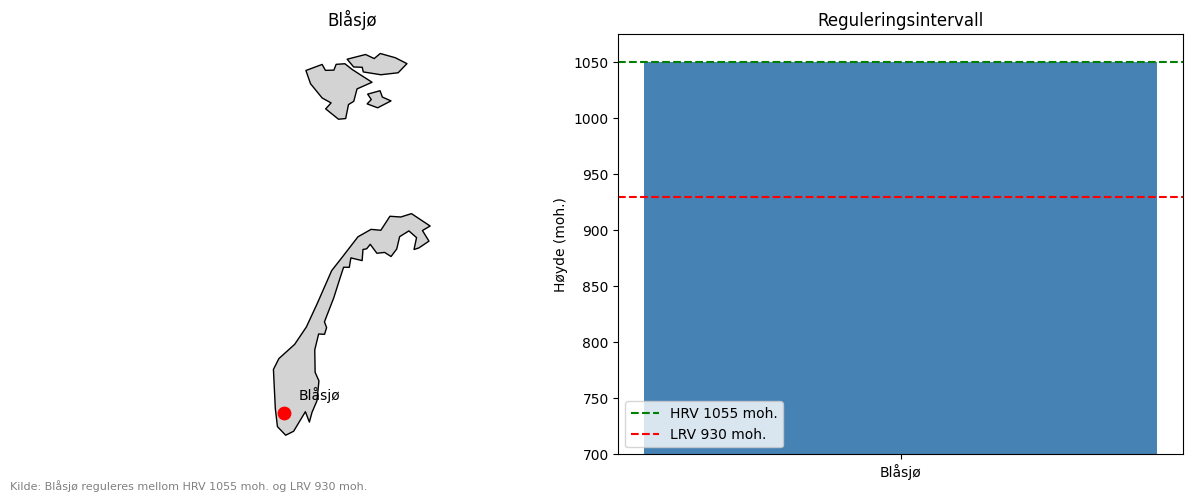

In [20]:
# TEST CELL
import geopandas as gpd
import matplotlib.pyplot as plt

# Blåsjø (omtrentlige koordinater)
lon = 6.85
lat = 59.37

# Verdier
HRV = 1055
LRV = 930

# Verdenskart
import geopandas as gpd

world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")

#print(world.columns)
norway = world[world["ADMIN"] == "Norway"]

# Figur med to paneler
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(12, 5),
    gridspec_kw={"width_ratios": [1.2, 1]}
)

# ------------------
# Kart
# ------------------

norway.plot(
    ax=ax1,
    color="lightgray",
    edgecolor="black"
)

ax1.scatter(
    lon, lat,
    color="red",
    s=80
)

ax1.annotate(
    "Blåsjø",
    (lon, lat),
    xytext=(10, 10),
    textcoords="offset points"
)

ax1.set_title("Blåsjø")
ax1.set_axis_off()

# ------------------
# HRV / LRV
# ------------------

ax2.bar(
    "Blåsjø",
    HRV - 705,
    bottom=700,
    color="steelblue"
)

ax2.axhline(
    1050,
    color="green",
    linestyle="--",
    label=f"HRV {HRV} moh."
)

ax2.axhline(
    LRV,
    color="red",
    linestyle="--",
    label=f"LRV {LRV} moh."
)

ax2.set_ylabel("Høyde (moh.)")
ax2.set_title("Reguleringsintervall")
ax2.set_ylim(700, 1075)
ax2.legend()

plt.figtext(
    0.01,
    0.01,
    "Kilde: Blåsjø reguleres mellom HRV 1055 moh. og LRV 930 moh.",
    fontsize=8,
    color="gray"
)

plt.tight_layout()
plt.show()

### Fyllingsgrad på 1,2,3

Hver uke samler [NVE](https://webfileservice.nve.no/API/PublishedFiles/Download/64edbe40-b965-4c90-a114-88162ffff454/201903383/3435075) vannstandsmålinger fra de 489 viktigste vannmagasinene, og publiserer de i sitt API. Det totale volumet er 56000 millioner kubikk som tilsvarer 87 TWh. 

For hvert magasin summeres energiekvivalentene, hvor mye energi som produseres per kubikk som går igjennom kraftverket ($kWh/m^3$) og multipliseres med fyllingsvolumet:
$$E_{M1} = V_{M1}\,(e_{K1}+e_{K2})$$

der:

- $E_{M1}$ = energiinnhold (GWh)
- $V_{M1}$ = fyllingsvolum (mill. m³)
- $e_{K1}, e_{K2}$ = energiekvivalenter (GWh/mill. m³)

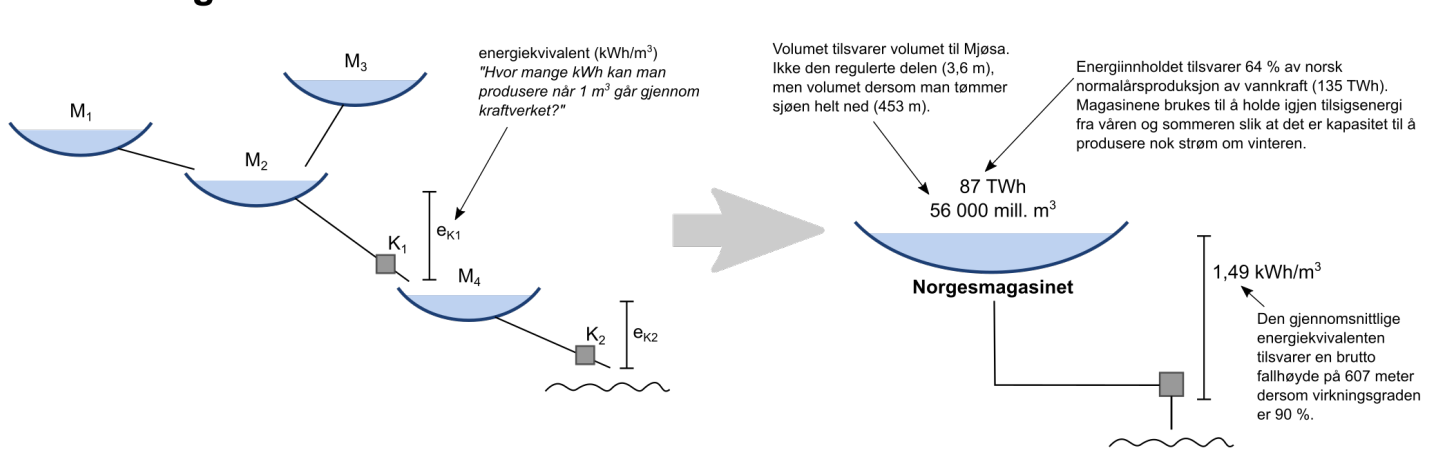

In [21]:
# TEST CELL
from IPython.display import Image, display
display(Image("../images/fgrad1.png"))

Energiinnholdet summeres og deles på det totale energiinnnholdet og slik finner man fyllingsgraden:

$$\text{Fyllingsgrad} = \frac{\sum E_{M_i,\text{uke }j}} {\sum E_{M_i,\text{maks}}}$$

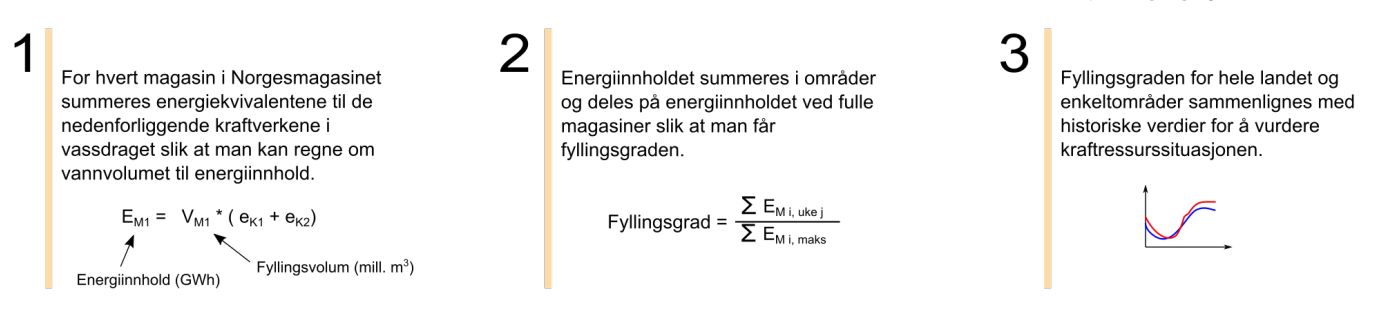

In [22]:
# TEST CELL
from IPython.display import Image, display
display(Image("../images/fgrad2.png"))

Vannstandsmålinger samles hver uke og publiseres onsdager kl. 13

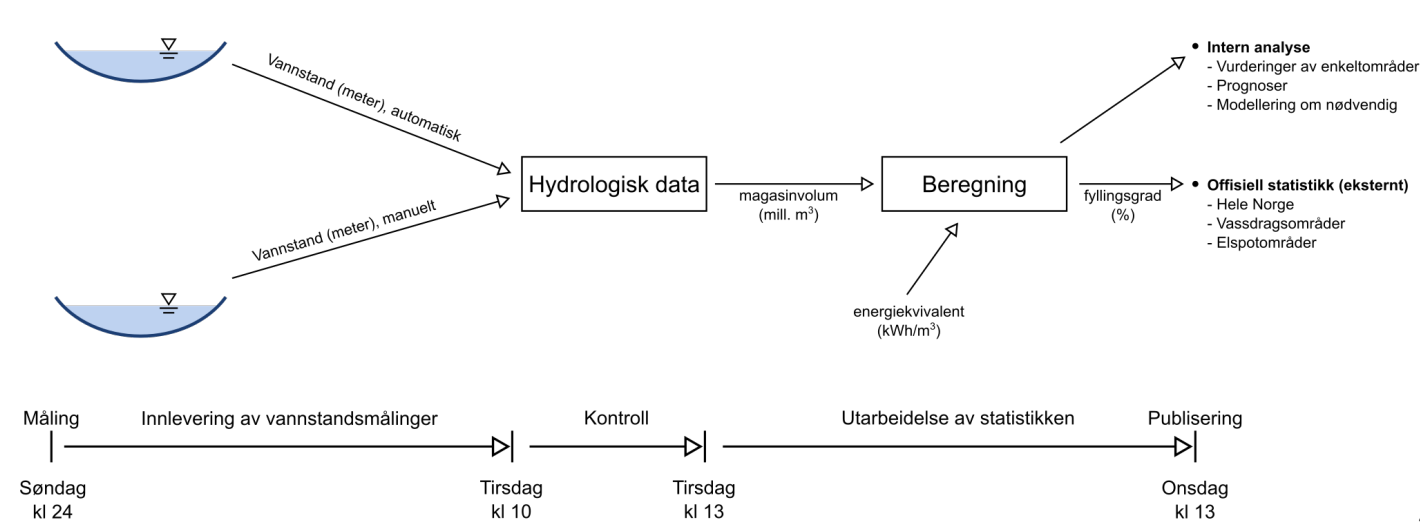

In [23]:
# TEST CELL
from IPython.display import Image, display
display(Image("../images/fgrad3.png"))

## Vannmagasinstatistikk

Ved å følge utviklingen fra uke til uke og sammenligne med historiske tidsseriedata fra de 20 siste årene kan man kontrollere tilsigsenergien og opprettholde forsyningssikkerhet. 

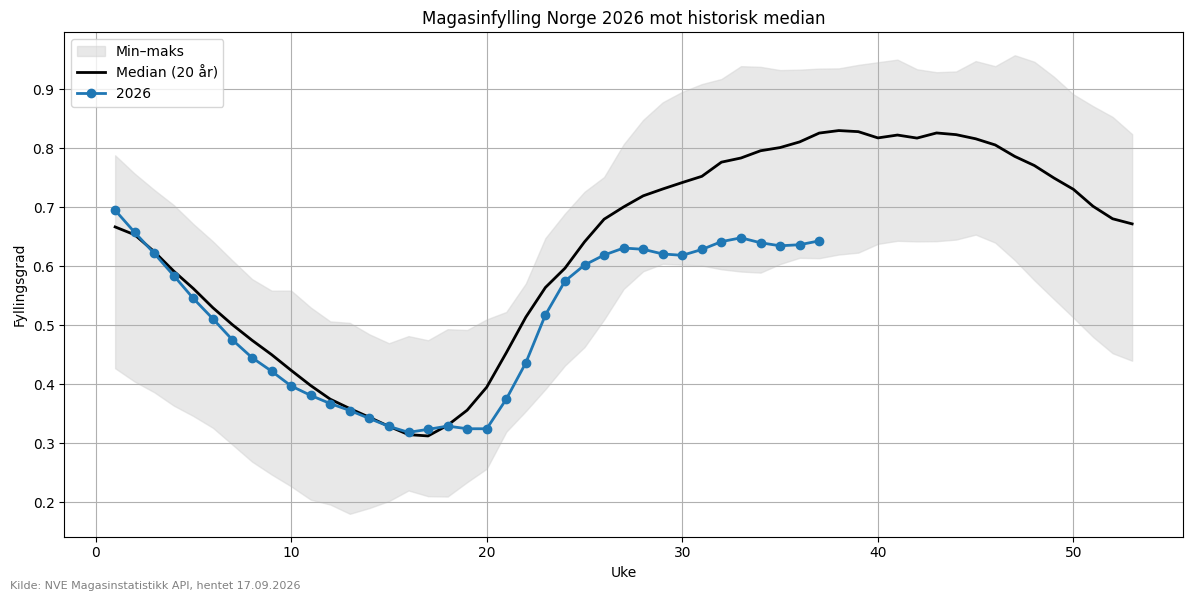

In [24]:
# TEST CELL
import pandas as pd
import matplotlib.pyplot as plt

# Historisk min/maks/median
url_ref = (
    "https://biapi.nve.no/magasinstatistikk/api/"
    "Magasinstatistikk/HentOffentligDataMinMaxMedian"
)

# Faktiske data
url_data = (
    "https://biapi.nve.no/magasinstatistikk/api/"
    "Magasinstatistikk/HentOffentligData"
)

ref = pd.read_json(url_ref)
df = pd.read_json(url_data)

# Hele Norge
ref = ref[ref["omrnr"] == 0].copy()
df = df[df["omrnr"] == 0].copy()

# Kun 2026
df = df[df["iso_aar"] == 2026].copy()

# Sortering
ref = ref.sort_values("iso_uke")
df = df.sort_values("iso_uke")

# Plot
plt.figure(figsize=(12,6))

plt.fill_between(
    ref["iso_uke"],
    ref["minFyllingsgrad"],
    ref["maxFyllingsgrad"],
    color="lightgray",
    alpha=0.5,
    label="Min–maks"
)

plt.plot(
    ref["iso_uke"],
    ref["medianFyllingsGrad"],
    color="black",
    linewidth=2,
    label="Median (20 år)"
)

plt.plot(
    df["iso_uke"],
    df["fyllingsgrad"],
    color="tab:blue",
    linewidth=2,
    marker="o",
    label="2026"
)

from datetime import date

plt.figtext(
    0.01, 0.01,
    f"Kilde: NVE Magasinstatistikk API, hentet {date.today():%d.%m.%Y}",
    ha="left",
    fontsize=8,
    color="gray"
)

plt.xlabel("Uke")
plt.ylabel("Fyllingsgrad")
plt.title("Magasinfylling Norge 2026 mot historisk median")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Import og eksport

Tilsigsenergien modereres også av utveksling av energi gjennom internasjonale kraftforbindelser. HVDC forbindelsene fasiliteres av back-to-back slik at synkronområder isoleres.

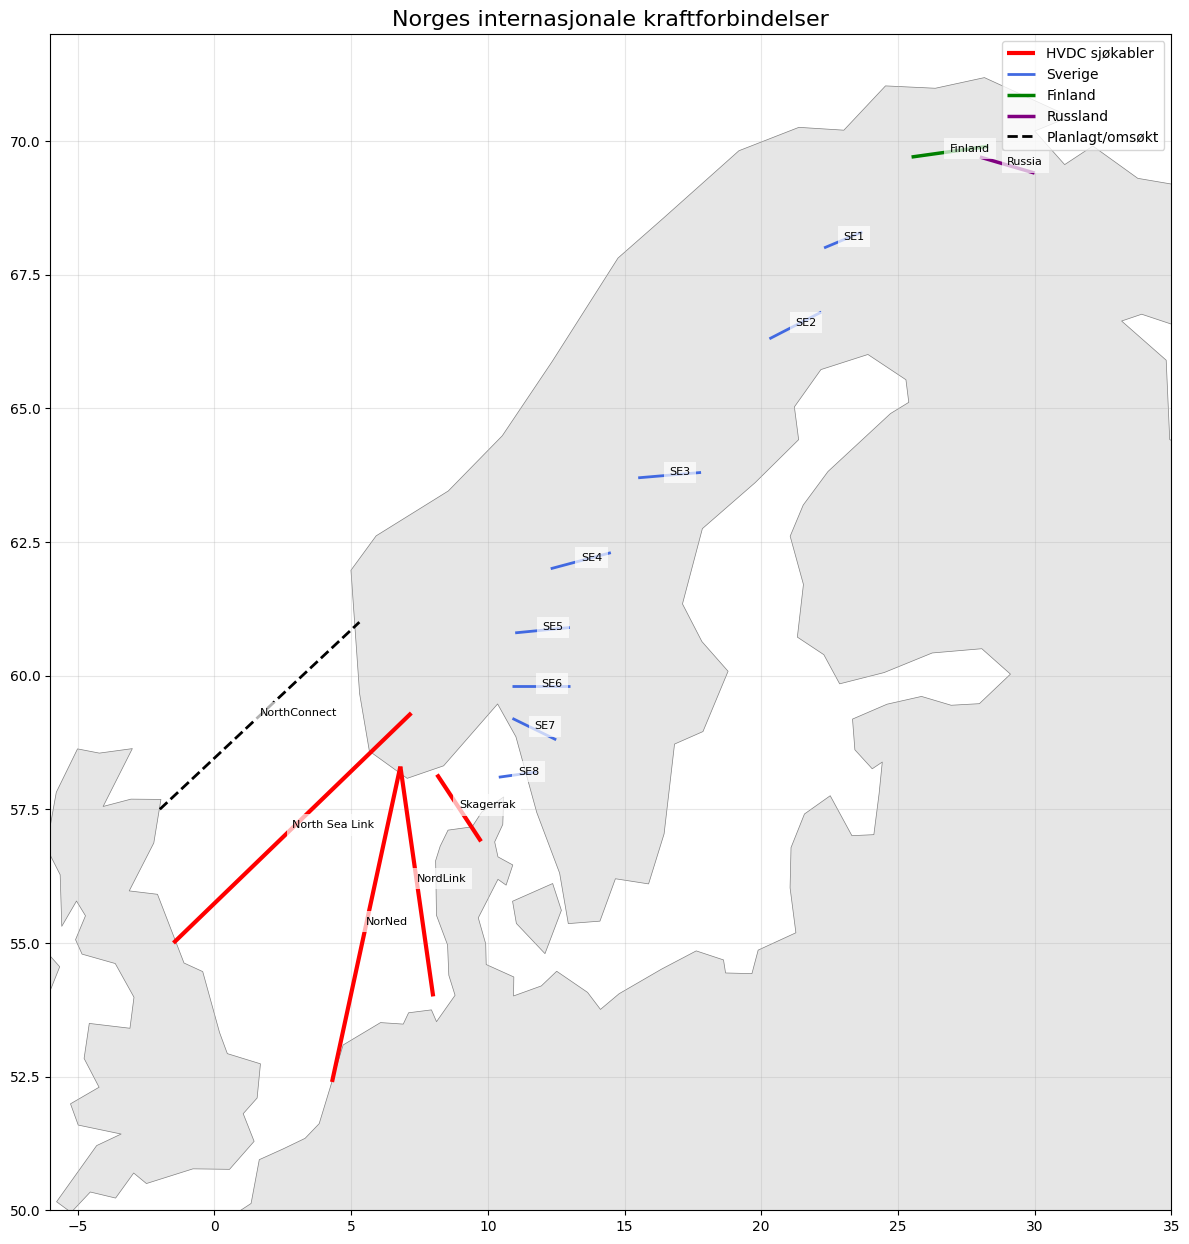

In [25]:
# TEST CELL
# pip install geopandas geodatasets matplotlib shapely

import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt
from shapely.geometry import LineString

# ==================================================
# BAKGRUNNSKART
# ==================================================

world = gpd.read_file(
    geodatasets.get_path("naturalearth.land")
)

# ==================================================
# EKSISTERENDE SJØKABLER (HVDC)
# ==================================================

subsea = {
    "Skagerrak": [
        (8.14, 58.15),     # Kristiansand
        (9.75, 56.9)       # Jylland
    ],

    "NorNed": [
        (6.8, 58.3),       # Feda
        (4.3, 52.4)        # Eemshaven
    ],

    "NordLink": [
        (6.8, 58.3),       # Tonstad/Feda-området
        (8.0, 54.0)        # Tyskland
    ],

    "North Sea Link": [
        (7.2, 59.3),       # Kvilldal
        (-1.5, 55.0)       # Blyth
    ],
}

# ==================================================
# LANDFORBINDELSER SVERIGE
# ==================================================

sweden = {
    "SE1": [(22.3, 68.0), (23.7, 68.3)],
    "SE2": [(20.3, 66.3), (22.2, 66.8)],
    "SE3": [(15.5, 63.7), (17.8, 63.8)],
    "SE4": [(12.3, 62.0), (14.5, 62.3)],
    "SE5": [(11.0, 60.8), (13.0, 60.9)],
    "SE6": [(10.9, 59.8), (13.0, 59.8)],
    "SE7": [(10.9, 59.2), (12.5, 58.8)],
    "SE8": [(10.4, 58.1), (11.8, 58.2)],
}

# ==================================================
# FINLAND
# ==================================================

finland = {
    "Finland": [
        (25.5, 69.7),
        (28.3, 69.9)
    ]
}

# ==================================================
# RUSSLAND
# ==================================================

russia = {
    "Russia": [
        (28.0, 69.7),
        (30.0, 69.4)
    ]
}

# ==================================================
# PLANLAGT / OMSØKT
# ==================================================

planned = {
    "NorthConnect": [
        (5.3, 61.0),
        (-2.0, 57.5)
    ]
}

# ==================================================
# HJELPEFUNKSJON
# ==================================================

def make_gdf(data):
    return gpd.GeoDataFrame(
        {"name": list(data.keys())},
        geometry=[LineString(v) for v in data.values()],
        crs="EPSG:4326"
    )

gdf_subsea   = make_gdf(subsea)
gdf_sweden   = make_gdf(sweden)
gdf_finland  = make_gdf(finland)
gdf_russia   = make_gdf(russia)
gdf_planned  = make_gdf(planned)

# ==================================================
# PLOTT
# ==================================================

fig, ax = plt.subplots(figsize=(12, 14))

world.plot(
    ax=ax,
    color="#E6E6E6",
    edgecolor="gray",
    linewidth=0.5
)

# Sjøkabler
gdf_subsea.plot(
    ax=ax,
    color="red",
    linewidth=3,
    label="HVDC sjøkabler"
)

# Sverige
gdf_sweden.plot(
    ax=ax,
    color="royalblue",
    linewidth=2,
    label="Sverige"
)

# Finland
gdf_finland.plot(
    ax=ax,
    color="green",
    linewidth=2.5,
    label="Finland"
)

# Russland
gdf_russia.plot(
    ax=ax,
    color="purple",
    linewidth=2.5,
    label="Russland"
)

# Planlagte
gdf_planned.plot(
    ax=ax,
    color="black",
    linewidth=2,
    linestyle="--",
    label="Planlagt/omsøkt"
)

# ==================================================
# ETIKETTER
# ==================================================

for gdf in [
    gdf_subsea,
    gdf_sweden,
    gdf_finland,
    gdf_russia,
    gdf_planned
]:
    for _, row in gdf.iterrows():

        p = row.geometry.interpolate(
            0.5,
            normalized=True
        )

        ax.text(
            p.x,
            p.y,
            row["name"],
            fontsize=8,
            bbox=dict(
                facecolor="white",
                alpha=0.7,
                edgecolor="none"
            )
        )

# ==================================================
# UTSNITT
# ==================================================

ax.set_xlim(-6, 35)
ax.set_ylim(50, 72)

ax.set_title(
    "Norges internasjonale kraftforbindelser",
    fontsize=16
)

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
# TEST CELL
import requests
from pyjstat import pyjstat

TABLE = "08307"

query = {
    "query": [{
        "code": "ContentsCode",
        "selection": {
            "filter": "item",
            "values": ["Import", "Eksport"]
        }
    }],
    "response": {
        "format": "json-stat2"
    }
}

url = f"https://data.ssb.no/api/v0/en/table/{TABLE}"

df = pyjstat.Dataset.read(
    requests.post(url, json=query).text
).write("dataframe")

#display(df.tail())

df_wide = df.pivot(
    index="year",
    columns="contents",
    values="value"
)


df_wide = df_wide.rename(columns={
    "Exports": "Eksport",
    "Imports": "Import"
})

df_wide.index = pd.to_datetime(
    df_wide.index.astype(str),
    format="%Y"
)


Statistikkbanken til SSB i tabell 08307 inneholder også statistikkvariablene import og eksport og vi gjør et nytt kall til APi-et mot disse verdiene.

```python
query = {
    "query": [{
        "code": "ContentsCode",
        "selection": {
            "filter": "item",
            "values": ["Import", "Eksport"]
        }
    }],
    "response": {
        "format": "json-stat2"
    }
}
```

Fra 2000 til i dag eksporterte vi i gjenomsnitt 18299 GWh og importerte 8698 GWh.

In [27]:
df_wide.loc["2000":].mean()

contents
Eksport    18299.884615
Import      8698.846154
dtype: float64

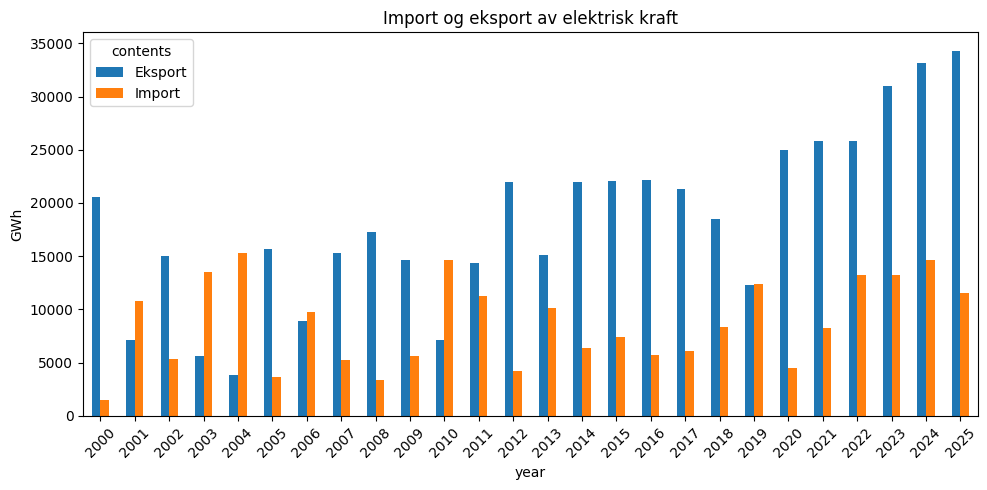

In [28]:
# TEST CELL
df_plot = df_wide.loc["2000":]

ax = df_plot.plot(
    kind="bar",
    figsize=(10, 5),
    color=["tab:blue", "tab:orange"]
)

ax.set_title("Import og eksport av elektrisk kraft")
ax.set_ylabel("GWh")

# Vis kun år
ax.set_xticklabels(
[d.strftime("%Y") for d in df_plot.index],
rotation=45)

plt.tight_layout()
plt.show()